# 3장 네트워크 중심성을 활용한 언어 자료 분석

## 1. 네트워크 지표들

3장에서는 2장에서 배운 기법을 사용하여 언어 자료를 네트워크 자료로 전환했다고 가정한 후, 그것에서 구조적 정보를 읽어내는 여러 지표를 배울 것입니다. 그리고 그 구조적 정보가 마음의 구조 탐구에 어떤 역할을 하는지도 토론해 볼 것입니다. 

네트워크 과학에는 네트워크의 구조적 특징을 묘사하고 측정하는 다양한 지표가 존재합니다. 이들은 다양한 수준에서 네트워크의 특징을 측정하여 표현하는데요, 전체 네트워크 수준에서 구조적 정보를 묘사하기도 하고 (예를 들어 밀도, 클러스터링 계수 등이 있습니다), 노드 수준에서 해당 노드가 가진 네트워크 구조를 고려한 정보 (예를 들어 중심성이 있습니다)를 포착하기도 합니다. 나아가 링크는 물론 노드 쌍 수준에서도 구조적 정보가 존재할 수 있습니다. 

우리가 앞에서 언어 자료의 연결 정보를 행렬로 전환한 후, 그것을 다시 networkx라는 라이브러리를 활용해 graph라는 자료 구조로 전환한 이유는, 이런 다양한 지표를 편하게 산출하기 위해서 였습니다 (더불어서 시각화도 편하고요!). networkx를 비롯하여 유명한 라이브러리는 대부분의 유명한 네트워크 통계 지표를 간단한 함수 형태로 구현해뒀습니다. 그리고 그 함수는 각 라이브러리가 설정한 자료 구조에 적용할 수 있지요. 그래서 networkx가 요구하는 자료 구조 형태로 전환한 것이지요. 

무슨 말인지 싶으실텐데, 간단한 지표에 대해 알아보고, 그것을 손으로 계산하는 것과 networkx로 계산하는걸 비교해봅시다. 예를 들어 네트워크의 밀도 (density)는 네트워크 지표 중 가장 기초적인 것 중 하나입니다. 밀도는 이론적으로 존재할 수 있는 연결 중 실제로 얼마나 많은 연결이 존재하느냐에 대한 답입니다. 아래 그림을 보고 좀 더 설명드릴게요. 

<div style="text-align:center;">
    <img src="_static/figures/밀도 예시.jpg" width="500">
</div>

두 네트워크 중 어느쪽이 밀도가 더 높을까요? 오른쪽입니다. 오른쪽은 밀도가 1이고, 왼쪽은 0.5입니다. 계산하는 방식은 간단합니다. 밀도는 아래와 같은 논리로 계산됩니다. 

$$
\begin{aligned}
density &= \frac{\text{실제로 존재하는 링크 숫자}}{\text{존재할 수 있는 최대의 링크 숫자}}
\end{aligned}
$$

만약 어떤 네트워크의 노드 숫자를 n, 링크 숫자를 m이라고 한다고 하죠. 그러면 무방향 무가중 네트워크 (undirected unweighted network)를 기준으로 위의 논리를 아래와 같이 구체적으로 표현됩니다. 

$$
\begin{aligned}
density = \frac{m}{\frac{n(n-1)}{2}} = \frac{2m}{n(n-1)}
\end{aligned}
$$


수식은 간단합니다. 존재할 수 있는 최대의 링크 숫자는 해당 네트워크에 존재하는 노드쌍 숫자입니다. 하나의 노드쌍이 있으면, 그 둘을 이으면 링크가 되니까요. 네트워크에 존재하는 노드쌍 숫자는, n개의 노드에서 2개를 골라내는 갯수와 같고, 이건 우리가 고등학교 때 배웠듯이 $\frac{n(n-1)}{2}$로 계산이 되죠. 그걸 그냥 위 도식에 넣은 겁니다. 

networkx의 그래프 클래스로 전환한 이후에 이런 지표를 구하는 것은 매우 간단합니다. 실습을 위해 우리가 2장에서 만든 자료가 있다고 하죠. 전에 저장을 해뒀으니 아래와 같이 불러와봅시다. 

In [1]:
import pickle
import networkx as nx
import numpy as np

with open("data/g_count.pkl", "rb") as f:
    G_count = pickle.load(f)

with open("data/g_win.pkl", "rb") as f:
    G_win = pickle.load(f)


기억하시겠지만, G_count는 제가 가상으로 제공한 리뷰들에서 등장한 토큰들을 '두 토큰이 같은 문장에서 출현하면 서로 연결되었다고 가정'한 상태에서 만든 네트워크고, G_win은 '두 토큰이 window 2 내에서 함께 출현하면 서로 연결되었다고 가정'한 상태에서 만든 네트워크입니다. 이 두 네트워크의 밀도를 계산하는 것은 아래와 같이 매우 간단합니다. 

In [2]:
print(nx.density(G_count))
print(nx.density(G_win))

0.058177278401997504
0.03845193508114857


즉, nx.density라는 함수를 적용하기만 하면 되지요. 수치도 이해가 됩니다. G_win 쪽의 밀도가 약간 낮은데, 아무래도 window 기반으로 근접 출현만 연결로 가정할 경우 같은 문장에 출현해도 연결되지 않았다고 판정하는 경우가 있었을테니 자연스럽죠. 위의 수치를 우리가 직접 계산한다고 하면 아마 아래와 같이 할 수 있을 것입니다. G_win 만 해봅시다. 

In [3]:
print(nx.number_of_edges(G_win))
print(nx.number_of_nodes(G_win))

E = nx.number_of_edges(G_win)
C = nx.number_of_nodes(G_win)

theoretical_pair_count = C*(C-1)/2
density = E/theoretical_pair_count
print(density)

154
90
0.03845193508114857


이렇게 하는 것도 가능하지만, 너무 번거롭겠죠. 그래서 networkx가 이미 구현해 놓은 함수들을 활용하는 편이 속도나 안정성 면에서 좋은 옵션이 될 것입니다. 

그래서 만약 언어 자료에서 네트워크 정보를 추출하고, 그걸 심지어 networkx 같은 라이브러리의 자료구조로 전환해 뒀다면, 네트워크 지표의 계산 자체는 매우 간단한 일이 됩니다. 명령어 한 줄이며 끝납니다. 그렇기에 오히려 중요한 것은 **'이 지표가 내가 다루는 토큰들의 네트워크에서 뭘 의미하느냐'** 를 이해하고, 그것을 각자가 마음의 구조를 탐구하는데 활용하는 일이죠. 이걸 위해서는 지표가 어떻게 계산되는지 정확히 이해하고, 그것이 나의 데이터의 어떤 면을 보여주는지 판단하는 과정이 필요합니다. 

그런 의미에서 저는 '중심성' (centrality) 계열의 네트워크 지표들이 언어 네트워크에서 마음의 구조에 대한 여러 정보를 제공하는데 매우 중요한 역할을 한다고 생각합니다. 이 중심성 지표들은 각자 나름의 기준으로 각 노드가 이 네트워크에서 얼마나 중심적인지 표현합니다. 이건 어떤 언어 자료의 '중심 개념'이나 '핵심 아이디어'를 파악하는데 유용한 정보를 제공합니다. 그리고 이런 중심성 지표를 networkx의 명령어를 가지고 계산하는건 정말 쉬운 일입니다. 하지만 이를 잘 활용하기 위해서는, 각 지표가 어떤 구조적 정보를 요약하는지, 그렇게 요약하는 이유는 무엇인지, 우리의 탐구에서 이 정보가 어떻게 활용될 수 있는지 생각해보는 과정이 필요합니다. 이를 위해 우리는 우선 여러 중심성 지표의 논리와 활용 가능성을 이론적으로 탐색해 볼 것입니다. 

## 2. 중심성 지표의 논리와 배경

자 이제 본격적으로 중심성 (centrality) 에 대해서 논의해 봅시다. Centrality란 네트워크 안에 있는 노드가 네트워크 구조를 고려했을 때 얼마나 중요하고 중심적인지 표현하는 숫자나 순위입니다. 여기서 노드의 중요도를 네트워크의 관점에서, 즉 그 노드가 가진 연결과 네트워크에서 차지하는 위치를 고려하여 평가했다는 점에 핵심이 있습니다. 

네트워크를 고려하면 뭐가 달라지는지 직관적으로 이해하기 위해서 간단한 사례를 들어봅시다. 예를 들어 우리가 '조원광'이라는 가상의 싱어송라이터의 정신세계가 궁금해서, 그 사람이 작사한 노래 가사를 모아서 분석한다고 칩시다. 그리고 이 작사가가 가진 서사의 핵심 키워드 혹은 중심 단어가 무엇인지 궁금하다고 가정하죠. 가장 간단한 접근은 출현 빈도에 기반한 판단일 것입니다. 즉 어떤 단어가 여러 곡에서 가장 많이 출현했는지 보는거죠. 

괜찮은 접근일 수 있지만, 동시에 노이즈에 취약하기도 합니다. '우연히' 혹은 '별 의미없이' 많이 쓰이는 단어들도 존재할 수 있거든요. 예를 들어 조원광이 자기를 드러내기 좋아하는 사람이라, 노래의 처음과 중간과 끝에 'WJ'라는 단어를 (Wonkwang Jo를 줄인거죠) 매번 넣었다고 해봅시다. 그러면 WJ는 출현 빈도가 매우 높을 것입니다. 그런데 그래서 이 단어가 중요할까요? 조원광의 성격을 보기에 중요할 수는 있을지 모르겠는데, 세계관이나 정신세계를 보기에 적절할지는 잘 모르겠습니다. 

반면 네트워크 정보를 활용하면 어떨까요? 즉 그 사람의 가사로 단어 (혹은 토큰) 네트워크를 구성하는 것입니다. 그리고 그 네트워크에서 가장 '중심적인' 단어를 찾는거죠. 중심성을 판단하기 위해 '각 단어가 한 문장에서 함께 등장한 단어의 종류수'를 사용합시다. 뒤에서 좀 더 자세히 이야기하겠지만, 이런 정의는 Degree centrality라고 할 수 있습니다. 이런 지표가 높은 값을 가지는 단어는 **여러 개념이나 관념에 대해 이야기할 때, 단골로 함께 쓰이거나 서사의 시작점이 된 단어**일 공산이 큽니다. 반면 단독으로 많이 쓰인 단어는 이 지표가 높을 수가 없지요. 중요성에 대해 판단할 때 그저 혼자만 많이 쓰인 단어와 여러 단어가 활용될 때 함께 늘 등장하여 의미 생성의 축이 된 단어를 비교한다면, 뭐가 더 주목할 만한 단어인지 선택하는 것은 그리 어렵지 않을 것입니다. 즉, 중심성을 언어 분석에 적용한다면, 그것은 언어 구성 요소가 맺고 있는 상호 관계를 고려하여 중요성을 색다른 각도로 지적하는 힘을 발휘할 수 있습니다. 

그래서 지금부터 여러 중심성 지표에 대해 말씀드리려고 합니다. 중심성 지표들을 설명하는 과정에서 여러 네트워크 과학 책을 참고하였습니다. 특히 Mark Newman의 *Networks*와 Wasserman and Faust의 *Social Network Analysis*를 많이 참조하였습니다. 이 책들에는 더 자세한 설명들이 있으니, 관심있으신 분들께서는 직접 읽어보시는 것도 좋을 것 같습니다. 

### 2.1. Degree centrality

구체적인 지표를 살펴보면서 이야기를 더 이어나가보겠습니다. 우선 중심성에서 가장 간단한 지표는 degree centrality입니다. 따로 이름이 붙어 있지만, 사실 degree centrality는 그냥 degree, 즉 링크수입니다. 네트워크 과학에서 degree는 개별 노드에 부여되는 숫자이고, 그 노드와 연결된 링크의 개수를 가리킵니다. 그래서 번역할 때 '디그리'라고 음역하기도 하고, '링크수'라는 의역이 활용되기도 합니다. degree centrality는 어떤 노드의 degree, 즉 링크수가 centrality의 지표가 될 수 있음을 주장합니다. 이웃 노드가 많으면 그 네트워크의 중심에 있다고 보는 것이지요. 

네트워크에서 degree라는 용어의 사용을 처음 보시는 분들을 위해 간단히 한 번 더 설명하자면, 우리가 위에서 썼던 저 네트워크 이미지에서 A의 degree가 왼쪽에서는 2, 오른쪽에서는 3이 됩니다. 

<div style="text-align:center;">
    <img src="_static/figures/밀도 예시.jpg" width="500">
</div>


다만 실제로 degree centrality를 계산할 때 degree를 그대로 활용하는 경우는 드뭅니다. 왜냐하면 degree는 네트워크 규모에 영향을 받기 때문입니다. 비방향이며 자기 순환 연결이 없는 네트워크 (undirected network without self-loop)를 가정할 때, 어떤 노드 degree의 최대값은 '노드숫자-1'입니다. 자기 이외의 나머지 노드들과 모두 연결될 가능성이 있으니까요. 그러면 노드 숫자가 많은 큰 네트워크일 수록 degree의 상한이 높아집니다. 그래서 서로 다른 네트워크에 속한 노드들의 중심성을 단순한 degree로 비교하기는 어렵지요. 사정이 동일하다면 네트워크 규모가 큰 쪽의 노드의 degree가 자연스럽게 더 클 것이기 때문입니다. 그래서 보통 '노드숫자-1', 즉 이론적 최대치로 디그리/링크수를 나눠서 0과 1사이로 정규화합니다. 아래처럼 한다는 말입니다. 

$$
\begin{aligned}
\frac{\text{degree}(v)}{n-1}
\end{aligned}
$$


언어 네트워크에 degree centrality가 적용되면, '어떤 토큰이 얼마나 다양한 토큰과 연결되어 있는가?'를 가리키는 지표가 되곤 합니다. (보통 degree를 계산할 때 weight는 고려하지 않습니다. 애초에 degree가 링크의 숫자를 가리키기 위함이지, 링크의 강도를 고려하는 지표는 아니기 때문입니다. weight를 고려한 계산이 있기는 하지만, 제 경험상 그리 많이 활용되지는 않습니다. 해석이 좀 복잡해지거든요.) Degree centrality가 높으면 매우 다양한 개념 혹은 관념과 연결되어 작동하는 토큰이라고 해석이 가능해지는 셈이지요. 

그리고 이걸 좀 적극적으로 해석하면, 토큰 네트워크에서 degree centrality가 높은 토큰은 '여러 종류의 이야기나 사유가 펼쳐지기 위해 축으로 삼는 토큰'일 가능성이 있습니다. 여러 이야기 혹은 개념이 이 토큰과 함께 등장하여 의미를 만들었을 공산이 있기 때문입니다. 그런 의미에서 degree centrality가 높은 토큰이 '중심 개념'을 가리키고 있을 가능성이 있다고 해석할 수도 있을 것입니다. 

### 2.2. Eigenvector centrality

Degree centrality가 다소 단순해 보이지만, 이 정도만 해도 '네트워크의 위치를 고려한다'는 면은 이미 충족하기에 유용한 경우가 많습니다. 하지만 단순하기에 네트워크의 위치나 정보를 충분히 활용하지 못하는 면도 있습니다. 가장 아쉬운 점은 **모든 이웃을 동일하게 취급한다**는 것입니다. 디그리 혹은 링크수에서 개별 링크는 모두 동일한 가중치를 가집니다. 

하지만 정말 그럴까요. 친구가 3명인 두 사람이 있다고 합시다. 한 사람의 친구 3명은 평범한 사람들입니다. 반면 다른 한 사람의 친구는 대기업 임원, 유튜브 스타, 고위 공직자입니다. 두 사람이 소셜 네트워크에서 가지는 중요도가 동일하다고 볼 수 있을까요? 그렇게 보기는 어려울 것입니다.

토큰들의 네트워크에서도 비슷하게 생각해 볼 수 있을 것입니다. 두 단어가 연결된 단어 종류의 숫자가 동일하다고 해도, 어떤 단어와 연결되어 있는지에 따라 중요도를 다르게 판단할 수 있습니다. 예를 들어 동일하게 10개의 다른 단어와 연결되어 있는 두 단어 A와 B가 있다고 해보죠. A와 연결된 10개 단어는 A와 함께 등장하여 연결된 것 이외에는 특별히 활용되는 일이 잘 없는 반면 (예를 들어 특수한 신조어 등), B와 연결된 10개 단어는 B 이외에도 다른 단어들과 활발히 연결되어 있다고 해봅시다. 그 경우 B가 개념이나 의미 지형에서 좀 더 중요한 것은 그리 어렵지 않게 추측할 수 있습니다. 앞서 말한 '여러 서사와 개념 구성에서 함께 등장하여 의미를 형성하는 토큰'도 B일 공산이 크죠. 

Eigenvector centrality는 바로 이런 지점을 개선하기 위한 지표입니다. 앞서 말한 문제는 노드의 중심성을 볼 때 그와 연결된 이웃 노드들을 모두 동일하게 취급하기에 생기는 약점입니다. 그렇다면, 어떤 노드의 이웃 노드들을 동일하게 취급하는 대신, 그 이웃 노드들이 가지는 중심성의 합에 비례하여 어떤 노드의 중심성을 매기도록 설계하면 어떨까요? 예를 들어 A라는 노드가 5만큼 중요한 노드 B와 연결되면, 1만큼 중요한 노드 C와 연결되었을 때보다 A의 중심성 점수에 더 많은 증가가 있도록 하는 것입니다. Eigenvector centrality는 이를 구현한 지표입니다. 

그런데 이게 생각보다 쉽지 않습니다. 필요성은 쉽게 인식할 수 있지만, 이를 만족하는 숫자를 떠올리기 어렵습니다. 앞서 나온 degree centrality에서 출발해 봅시다. A의 새로운 centrality 점수를 A 이웃의 degree centrality를 고려하여 부여한다고 해봅시다. 예를 들어 A의 이웃이 셋 있는데, 1번 이웃은 degree가 3, 2번 이웃은 5, 3번 이웃은 2라고 합시다. 그러면 자연스럽게 하려면, A의 뭔가 새로운 centrality는 $\text{적절한 상수}\times(3+5+2)$ 정도로 잡을 수 있을 것입니다. 그러면 A의 새로운 centrality는 각 링크의 기여가 이웃들의 중심성에 비례하게 잡힐 것입니다. 이건 적어도 degree centrality와는 다르겠죠. 

그런데 그렇게 되면, 순차적으로 모든 걸 바꿔야 하는 문제가 생깁니다. 이제 A의 이웃들의 중심성을 계산하는 상황을 생각해봅시다. 그 이웃들은 A의 중심성을 신경써서 자신의 중심성을 계산해야 합니다. degree centrality 건, 아니면 새로 계산된 중심성이건 마찬가지이죠. 그러면 A 이웃들의 중심성도 변화해야 합니다. 그러면 A는 어떤가요? 만약 '이웃들 중심성의 합에 비례하게'라는 원칙을 지킨다면, A도 다시 바뀌어야 합니다.

난감합니다. A의 새로운 중심성을 정의하니 A의 이웃들의 중심성이 바뀌고, 그러니 다시 A가 바뀌어야 하는 상황이죠.

그런데 흥미로운 것은 이 상황을 수식으로 정리해보면, 선형대수 (linear algebra) 에서 흔히 보던 수식이 튀어나옵니다. Eigenvector와 eigenvalue를 구할 때 보던 방정식이 그것입니다. 먼저 이 상황을 수식으로 정리해봅시다. 우리는 어떤 미지의 점수, 즉 새로운 centrality 점수가 네트워크의 모든 노드에 부여되기를 원합니다. 이때 어떤 노드의 점수는 그 노드와 연결된 노드들의 점수의 합에 비례해야 합니다. 그래야 점수가 높은 노드와 연결되었을 때 점수가 낮은 노드와 연결되었을 때 점수보다 높아집니다. 수식으로 표현하면 다음과 같습니다. 

$$
\begin{aligned}
x_i = k^{-1}\sum_{j = 1}^n A_{ij}x_j
\end{aligned}
$$

수식을 좀 설명해보면 다음과 같습니다. i 번째 노드의 점수는 i가 아닌 노드들의 점수의 합에 비례하게 만들어집니다. 그런데 i와 연결된 노드들만 고려하고 싶습니다. 그래서 $\sum_{j = 1}^n A_{ij}x_j$ 파트가 생깁니다. 여기서 A는 인접 행렬(adjacency matrix), 즉 연결 정보를 담은 행렬입니다. 그런데 $A_{ij}$와 $x_j$를 곱해서 모두 더하게 되면, $A_{ij}$가 0이 아닐 때에만 $x_j$의 수치가 더해질 것입니다. 즉 'i와 연결된 노드들이 가진 점수의 총합'이 표현되는 것이지요. 그런 다음 적당한 상수를 곱해서 i번째 노드의 점수가 만들어지는 셈입니다. 

그런데 이걸 '모든 노드에 대한 연산'에 적용하기 위해 행렬과 벡터간 계산으로 만들고, 1/k를 반대쪽으로 옮긴다고 해보죠. 그럼 이런 형태가 됩니다. 

$$
kx = Ax
$$

그리고 양변의 순서만 바꾸면, 이렇게 되죠

$$ 
Ax = kx
$$

그리고 이것은 선형 대수에서 eigenvector를 설명할 때 나오는 방정식의 형태입니다. 여기서 x를 A의 eigenvector, 고유 벡터라고 부릅니다. 우리가 원하는 개념을 수식으로 표현해서 정리했더니 이런 고유벡터의 정의가 나왔다는 건 무슨 말일까요? 그건 A의 고유 벡터(eigenvector)를 구하면, 바로 그것이 우리가 원하는 조건을 만족하는, 즉 어떤 노드에 주어진 점수가 그 노드와 연결된 다른 노드에 주어진 점수의 합에 비례하게 설정된다는 말이라고 할 수 있지요. 그래서 이를 중심성 점수로 삼고 eigenvector centrality라고 부르는 것입니다. 

Eigenvector를 접해보지 못하신 분도 많을테니, 위 수식에 대해 약간만 더 설명해보겠습니다. 일단 x를 어떻게 구하는지를 떠나서, 저 수식이 선언하고 주장하는 바가 무엇인지 살펴보면 좋습니다. 여기서 x는 이제 하나의 노드가 아니라 모든 노드의 중심성 점수를 담은 벡터라고 생각하면 됩니다. 열벡터 (column vector) 인 셈이지요. 만약 노드 숫자가 n이라면 (n,1)이라는 형태를 가진 벡터라고 생각하면 편하겠습니다. A는 n개 노드들 사이의 관계를 표현하는 행렬이니 (n,n) 형태를 가진 행렬이지요. 그 둘을 곱하면, A 있는 연결 정보를 고려하여, 각 노드의 이웃 노드들의 점수가 합쳐진 점수가 결과로 나옵니다. 잘 생각해보면 그렇습니다. 예를 들어 A 행렬의 1행은 1번 노드와 연결된 노드가 뭔지를 가리키는 행 벡터가 되는데, 그것과 x의 dot product가 Ax의 첫번째 값이 될 것입니다. 그리고 그건 1번째 노드와 연결된 노드들이 가지는 x점수 합이 됩니다. 그런데 그게 다시 kx로 표현되고 있는 것이지요. 이는 첫 번째 노드의 점수가 첫번째 노드와 연결된 노드들의 점수를 다 더해서 상수배를 한 것이다 (즉 비례한다) 라는 선언이기도 합니다. 

앞서 말했듯 이 x를 알아내는게 생각보다 쉽지 않습니다. 그런데 선형 대수에서는 정방 행렬이 주어지면 그 행렬의 eigenvector를 알아내는 방법이 잘 정리되어 있지요. 그래서 이를 계산하는 것은 그 표준적인 절차를 따르면 됩니다. 좀 더 정확히 말하면 leading eigenvector를 구해내고 그걸 중심성 점수로 삼는 것인데 (eigenvector는 여러 개 나올 수 있거든요), 더 자세한 설명이 필요하신 분은 선형대수 책을 참고하시면 좋습니다. 어쨌든 여기서 핵심은 **'이웃 노드의 중심성에 비례하는 중심성'** 이 개념적으로 매력적이지만 모든 노드에 이 점수를 배정하는 간단한 방법을 직관적으로 떠올리기가 쉽지 않은데, **네트워크의 연결 정보를 담은 인접 행렬(adjacency matrix)의 고유 벡터(eigenvector)를 구하면 그것이 이런 개념에 정확히 부합하는 중심성 점수가 된다** 는 것입니다. 그래서 Eigenvector centrality라고 부르는 셈이지요. 번역은 그대로 음역하는 경우가 더 많지만, 소셜 네트워크 이론에서 활용될 때에는 '위세 중심성'이라고 의역하는 경우도 있습니다. 

### 2.3. Katz centrality (alpha centrality)

이런 eigenvector centrality는 혁신적인 면이 있지만, 상황에 따라서 조금씩 보완이 필요한 경우가 생깁니다. 대표적인 것이 directed network에서 발생하는 문제입니다. 사실 eigenvector centrality는 undirected network에서 가장 잘 작동합니다. 그런데 directed network에 가면 소소한 문제가 생깁니다. in-degree가 0인 노드 때문에 생기는 문제입니다. 앞서 degree가 링크수라고 말씀드렸습니다. 그래서 링크수라는 번역어를 쓰기도 하지요. 그런데 네트워크에 방향이 있으면 이 degree, 링크수에 두 종류가 생깁니다. 즉 어떤 노드로 '들어오는 링크의 숫자'(in-degree)와 해당 노드로부터 '나가는 링크의 숫자'(out-degree)가 분리되는 것입니다. 트위터 팔로윙 네트워크 같은걸 생각해보죠. 누군가의 팔로워 숫자 (즉 그 사람을 팔로윙 하는 사람 숫자)는 in-degree라고 할 수 있습니다. 반면 누군가가 팔로우하는 숫자는 out-degree라고 할 수 있겠네요. 토큰 네트워크에서도 수식의 방향 같은 것을 고려하면 directed network를 만들어 볼 수 있습니다. 여러 형용사 토큰으로부터 수식을 받는 토큰은 in-degree가 커지고, 여러 체언 토큰을 수식하는 토큰은 out-degree가 커지는 셈이지요.

그런데 '이웃 노드의 중심성에 비례하도록 중심성을 설정한다'고 할 때, '이웃'은 어떻게 판단해야 할까요? 어떤 노드의 이웃은, 그 노드로 링크를 뻗은 노드만 고려해야 할까요, 아니면 그 노드가 링크를 뻗은 노드까지 고려해야 할까요? 즉 그 노드의 in-link만 고려하면 될까요, out-link까지 고려해야 할까요? 상황에 따라 판단이 달라지겠지만, 많은 경우 어떤 노드를 향해 링크를 뻗어오는 노드가 해당 노드에게 유의미한 경우가 더 많습니다. Eigenvector centrality 같은 지표의 핵심을 직관적으로 다시 설명하자면, 어떤 노드가 '더 잘 나가는 (중심적인)' 노드와 이웃이면 덩달아 그 노드도 좀 더 중심적인 위치라고 판단할 수 있다는 것입니다. 그 발상이 타당하려면, 이웃 노드가 적극적으로 해당 노드를 이웃으로 삼아야 하지요. 예를 들어 내가 소셜 미디어에서 미국 대통령을 팔로우 하고 있다는 것이 내 중심성에 영향을 미치지는 않지만 (그는 제가 팔로우하는지 알지도 못할 것입니다), 미국 대통령이 나를 팔로우하는 것은 내 중심성에 큰 영향을 미치니까요. 그래서 in-degree와 in-link를 기준으로 중심성을 설정하는게 자연스러운 경우가 많습니다. 문제는, 그렇게 하면 in-degree가 0인 노드가 꽤 많이 발생할 수 있다는 점입니다. 즉 in-link 없이 out-link만 있는 경우가 directed network에서는 종종 생깁니다. 그러면 지금처럼 '이웃 노드의 중심성의 합에 비례하도록 세팅된 중심성'을 그 노드에게 부여할 수가 없게 됩니다. 왜냐하면 이웃이 없으니, 이웃 중심성 합도 0이죠. 그런데 0에 비례하는건 0밖에 없거든요. 더 큰 문제는, 그러면 이 중심성이 0인 노드로부터 링크를 받고 있는 노드들의 점수도 애매해진다는 것입니다. 예를 들어 10개의 in-link를 보유한 노드를 생각해 봅시다. in-degree가 10인 노드죠. 그걸 A라고 합시다. 그런데 하필 이 노드에 링크를 보내는 노드들은 모두 in-link가 없다고 가정해보죠. 즉, A를 향해 링크를 뻗고 있는 노드들은 모두 in-degree가 0입니다. 앞서 말한 것처럼 in-degree가 0인 노드들은 이웃이 없기에 중심성이 0일 수 밖에 없습니다. 그런데 이러다보니 A는 유의미한 이웃이 10개가 있지만, 그 중심성을 모두 합쳐도 여전히 0입니다. 그러니 A도 0이 될 수 밖에 없습니다. 이는 직관적으로 타당해보이지 않습니다. 적어도 A 노드는 뭔가 중심성을 가져야 할 것 같습니다. in-degree가 0인 노드가 0이 되는건 그렇다쳐도, A까지 0이 되는건 좀 이상해 보이죠. 

Katz centrality 혹은 alpha centrality는 이 상황을 해결하기 위해 노드들에 기본 점수를 부여하는 지표입니다. 예를 들어 중심성 지표를 아래와 같이 정의해봅시다. 
$$
x_i = a\sum_{j=1}^n A_{ij}x_j + b, \quad \text{where } a > 0, b > 0
$$

의도가 명확한데, 모든 노드가 기본 점수를 가지도록 하겠다는 것입니다. 주로 1을 b의 값으로 놓곤 합니다. 

이렇게 되면 앞서 말한 것처럼 in-degree가 0인 노드, 그리고 그런 노드돌로부터 링크를 받는 노드의 중심성 문제를 해결할 수 있습니다. in-degree가 0인 노드도 어느 정도 중심성을 갖게 됩니다. 기본점수죠. 그리고 in-degree가 0인 노드로부터 링크를 받는 노드들은 일정 부분 점수를 이전받아서 in-degree가 0인 노드보다 높은 중심성을 갖게 됩니다. 훨씬 자연스러운 셈입니다. 

참고로 말하자면 이 설정을 undirected network에도 쓸 수 있습니다. 기본점수를 더한다는 발상을 꼭 이 문제를 해결하기 위해서만 쓸 필요는 없기 때문입니다. 이런 '기본 점수를 부여한다'는 발상이 필요한 상황에서 쓰면 적절할 것입니다. 

### 2.4. Pagerank centrality

Pagerank centrality는 여기서 한 발 더 나아갑니다. Eigenvector centrality와 Katz centrality가 공통적으로 가지는 가정이 하나 있습니다. 그것은 어떤 노드가 가진 중심성이 그 노드의 이웃노드로 제한없이 이전된다는 점입니다. 즉 그 노드의 out-link가 100이든 10이든 상관없이, 그러니까 그 노드의 이웃이 10개든 100개든 상관없이, 그 노드의 이웃이기만 하면 동일한 점수가 이웃 노드의 중심성을 계산할 때 더해집니다. 그런데 이것이 타당한 가정일까요? 예를 들어 중심성이 동일한 수준으로 매우 높은 두 개의 노드가 있다고 해보죠. 하나는 out-link가 10입니다. 즉 그 노드에서 나가는 링크는 10개입니다. 다른 하나는 out-link가 100입니다. 전자는 10개의 노드에 점수를 나눠줍니다. 후자는 100개의 노드에 점수를 나눠줍니다. 두 노드가 나눠주는 점수는 같아야 할까요? 달라야 할까요? 네트워크의 종류에 따라 이전되는 중심성 점수가 out-degree에 반비례하도록 설정하는 것이 타당할 때가 있습니다. 인간 관계의 예를 떠올려봅시다. 똑같은 인기인이라도, 그 사람이 자신의 친구의 위세에 미치는 영향은 그 사람의 친구 숫자에 영향을 받는 것이 자연스럽습니다. 내가 그 사람의 친구 10명 중 한 명일 때와 100명 중 한 명일 때 그 사람의 중심성이 나에게 미치는 영향은 다르기 마련일테니까요. 

Pagerank centrality는 이점을 고려하기 위해 수식을 다음과 같이 추가합니다. 

$$
x_i = a\sum_{j=1}^nA_{ij}\frac{x_j}{k_j^{out}}+b
$$

Katz centrality 처럼 기본 점수를 줍니다. 그런데 이웃 노드로부터 이전 받는 점수가 $x_j$가 아니라, $x_j$를 $k_j^{out}$로 나눈 값이라는 점이 추가되었습니다. 즉, 이웃 노드의 중심성 점수를 out-degree로 나눠서 합치겠다는 말입니다. 그리고 좀 더 명확히 하자면, 저기 b도 그냥 1로 잡는게 아니라 $(1-a)\frac{1}{N}$ 이렇게 설정하여 앞에 나온 a와 연동시킵니다. 지금 우리에게 아주 중요한 사항은 아니지만요. 

많이 알려져 있듯이 Pagerank centrality는 구글이 좋은 검색 결과를 사용자에게 제공하기 위해 활용된 지표이기도 합니다. 구글 같은 검색 엔진이 해주는 중요한 일 중 하나는 '유저의 검색어에 기반하여 중요한 인터넷 페이지를 식별하여 제공하는것'이라고 할 수 있습니다. 즉 유저의 검색어를 포함하거나 그와 관련된 인터넷의 무수한 페이지들 중 '중요한' 페이지를 알아내야 하는거죠. 여기서 네트워크 정보를 활용할 수 있습니다. '다른 페이지로부터 링크를 많이 받으면 중요하다'고 판단할 수 있고, 여기서 더 나아가 '더 중심적인 페이지로부터 링크를 받으면 덩달아 중심적이 된다'는 가정을 넣을 수 있지요. 우리가 이제까지 배운 아이디어를 활용할 수 있는 것입니다. 구글은 여기에 더해 한 페이지가 이전할 수 있는 중심성 혹은 중요도를 그 페이지의 out-degree를 고려하여 결정하는 알고리즘을 고안하였는데, 그게 Pagerank 였습니다. 그리고 그 이름을 딴 Pagerank centrality라는 중심성을 여전히 다른 영역에서도 활용하고 있지요. 

Eigenvector centrality, Katz centrality, Pagerank centrality는 모두 '중심성이 높은 노드와의 연결이 중심성 점수에 좀 더 기여한다'는 아이디어를 실현하기 위한 지표들입니다. 언어를 재료로 한 토큰 네트워크에서 이 지표들은 어떤 의미를 가질까요? 일단 중요한 토큰과 연결된 토큰은 링크수가 같아도 좀 더 중요하다는 발상은 그리 부자연스러워보이지 않습니다. 그런 의미에서 eigenvector centrality 계열의 지표를 적용해보는 것은 degree centrality를 보완하여 '실질적 중심 개념'을 포착하는 용도로 쓰일 가능성이 있다고 생각합니다. 즉 degree centrality가 제공하는 '다양한 토큰과의 연결'이라는 정보에 더해서 '중요 토큰과의 연결이 얼마나 많은지'를 측정해주기에 '여러 서사와 개념 구성에서 함께 등장하여 의미를 형성하는 토큰'을 포착하는 좀 더 정교한 방법으로 활용할 가능성이 있다는 말입니다. 

다만 토큰 간 네트워크에서 '방향'을 설정하는 것은 신중해야 할 것입니다. 방향을 설정하는게 생각보다 쉽지 않습니다. 명백한 문법적 의미 등이 수반되지 않는다면, 임의로 방향을 설정하는 것이 오히려 이상한 결과로 이어질 수 있습니다. 제 생각에는 방향성을 고려하지 않은 네트워크와 그 상태에서 적용하기 좋은 지표를 활용하는게 더 좋지 않나 싶습니다. 물론, 여러분이 창의적으로 활용하시고 그것에 타당한 기반이 있다면 그건 언제든 좋은 시도일 것입니다. 

### 2.5. Closeness centrality

조금 다른 방식의 중심성도 한 번 살펴봅시다. 중심성, 즉 네트워크에서 중심적인 정도를 정의하는 방식은 매우 다양할 수 있으니까요. 먼저 살펴볼 것은 closeness centrality입니다. Closeness centrality는 명칭에서 볼 수 있듯이 거리개념을 활용합니다. 기본 아이디어는 '다른 노드와 거리가 가까우면 그 노드를 중심적이라고 할 수 있다'는 것입니다. 다른 노드와 거리가 가까우면 그 노드와 상호작용하기 좋다는 점에 비추어보면 이 역시 타당한 면이 있는 접근입니다. 

지표의 수학적 정의는 다음과 같습니다. 우선 노드별로 자기 자신을 제외한 나머지 노드들과의 거리를 측정한 후 평균해 줍니다. 

$$
\begin{aligned}
l_i = \frac{1}{n-1}\sum_j d_{ij}
\end{aligned}
$$

이 숫자가 크면 다른 노드들로부터 거리가 평균적으로 멀다는 말이 됩니다. 우리는 중심성이 그 반대를 의미하기를 바랍니다. 즉 다른 노드들로부터 거리가 가까우면 더 중심적인 노드라 할 수 있고 그래서 숫자가 크기를 원하죠. 그래서 위에서 구한 평균 거리에 역수를 취해줍니다. 그게 closeness centrality의 기본형입니다. 

$$
\begin{aligned}
C_i = \frac{1}{l_i} = \frac{n-1}{\sum_j d_{ij}}
\end{aligned}
$$

앞서 말했듯이 Closeness centrality가 높으면 다른 노드들과의 평균 거리가 가깝다는 뜻이 됩니다. 그런 의미에서 중심적이라고 볼 수 있지요. 다만 계산에서 몇 가지 고려할 문제가 생깁니다. 우선 네트워크에 서로 연결되지 않은 노드쌍이 존재하면, closeness centrality를 계산하는데 문제가 발생할 수 있습니다. 해당 노드쌍 사이의 거리를 계산하는 것이 불가능해지기 때문입니다. 통상 연결되지 않았다면 거리를 무한대로 보는데, 그런 노드쌍이 하나만 있어도 closeness centrality 공식에서 $\sum_jd_{ij}$ 파트가 덩달아 무한대가 됩니다. 그러면 다른 노드와의 관계와 상관없이 closeness centrality가 0이 되어 버리죠. 이건 그리 합리적인 결론이라고 보기 어려울 것입니다. 그래서 서로 연결되지 않은 노드쌍의 거리를 특정한 상수로 설정하는 해결책이 존재합니다. 노드의 총 개수로 설정하는 것이 한 방법일 것입니다. 왜냐하면 그것이 이론적으로 발생할 수 있는 최대 거리 + 1이기 때문입니다. 이런 세팅은 보통 네트워크 분석 라이브러리 함수에 구현되어 있으니 잘 살펴보고 선택하면 됩니다. 

그러면 토큰 네트워크에서 closeness centrality는 어떤 의미를 가질까요? 즉 closeness centrality가 높은 토큰이 뭐라고 해석하면 좋을까요? 일단 closeness centrality가 높다면, 그 토큰이 다른 토큰과의 전반적인 거리가 짧다는 뜻이 됩니다. 그런데 그렇다고 이게 중심적인 개념을 가리킨다고 바로 해석하기가 다소 애매한 면이 있습니다. '간접 연결'이 토큰 네트워크에서 가지는 의미가 다소 모호한 면이 있기 때문입니다. 

사실 closeness centrality의 장점은 '간접 연결'을 고려한 중심성 판정입니다. degree centrality는 어떤 노드의 중심성을 그것과 직접적으로 연결된 노드들만을 가지고 판정하지요. 그런데 네트워크에서는 간접 연결이 존재할 수 있습니다. 친구도 있지만 '친구의 친구'도 있으니까요. 그리고 그 간접 연결이 의미를 가질 때도 많습니다. 소셜 네트워크 연구 중에서는 '친구의 친구의 친구'의 행복이나 건강 행동이 나에게 영향을 미친다는 유명한 연구 결과도 있지요. (이런 논문을 참조해보시면 좋습니다. Fowler, J. H., & Christakis, N. A. (2008). Dynamic spread of happiness in a large social network: longitudinal analysis over 20 years in the Framingham Heart Study. Bmj, 337.) closeness centality가 높은 노드는 간접 연결까지 고려했을 때 다른 노드와 관계나 상호작용이 원활하다고 할 수 있고, 그래서 중심적인 면이 있다고 할 수 있지요. 특히 정보나 전염력이 강한 바이러스처럼 간접 연결일 경우에도 충분히 쉽게 전파되는 현상을 연구하기 위해 네트워크를 볼 경우, 더더욱 중요한 구조적 지표가 됩니다. 

그런데 토큰 네트워크에서 간접 연결은 구체적으로 뭘 가리킬까요? 일단 토큰 네트워크에서 연결은 '공동 출현'이나 '근접 출현'을 가리키는 경우가 많습니다. 그러면 간접 연결은 이런거죠. '대통령'과 '장관'이 서로 함께 많이 쓰였다고 합시다. 같은 문장에 자주 출현했거나 가까이 출현했다는 말이죠. 그리고 '장관'은 '청문회'와 함께 많이 쓰일 수 있습니다. 그때 '대통령'과 '청문회'는 간접적으로, 즉 거리 2로 연결되어 있습니다. 이런 방식의 간접 연결은 소셜 네트워크에서 '친구의 친구'보다 직접적 상호작용 가능성이 더 작다고 봐야할 것입니다. 애초에 '공동 출현'이나 '근접 출현'에 기반한 연결은 직접적 상호작용을 포착해서 설정했다기보다, 상호작용이 있을 공산이 크다고 봐서 가정된 잠정적 연결에 가깝기 때문입니다. 당연히 단계가 진행될 수록 상호작용 가능성의 강도는 떨어질 수 밖에요. 

그러다보니 토큰 네트워크에서 다른 토큰과의 거리가 가깝다고 해서 그걸 바로 '중심 개념'으로 해석하기는 어려운 면이 있습니다. 그렇다고 의미가 없다고 볼 수는 없습니다. 제 생각에 전반적으로 다른 토큰과 거리가 가까운 토큰은 그 언어 자료가 가진 전반적인 세계관 혹은 언어 사용 패턴에 대해 정보를 제공해 줄 수 있습니다. 왜냐하면 어떤 토큰에서 출발하더라도 가까운 거리에서 발견할 수 있다면, 그 토큰은 그 언어 자료를 만든 사람들의 언어 사용에서 기본 개념이나 배경 개념을 담당하고 있을 공산이 있습니다. 즉 '중요하다'고 해석하기는 어려워도, '기본적으로 많이 사용되거나 다들 별 생각없이 받아들이는 전제에 해당한다'고 해석할 가능성은 있지요. 

요컨대 closeness centrality는 네트워크에서 전반적으로 다른 노드와 거리가 가까운 노드를 식별하는데 유용합니다. 제가 보기에 토큰 네트워크에서 이 중심성이 높은 토큰은 '중심적이다'라고 해석하기는 어려울지 몰라도, 그 자료의 기본 개념이나 배경을 이루는 전제를 식별하는데 유용할 수는 있을 듯합니다. 

### 2.6. Betweenness centrality

마지막으로 betweenness centrality를 살펴봅시다. Betweenness centrality는 네트워크에서 '매개'의 역할에 주목한 개념입니다. 어떤 노드의 중심성을 그 노드 이외의 다른 노드쌍들의 경로를 살펴보면서 계산합니다. 즉 어떤 노드가 나머지 노드쌍들의 최단 경로에 얼마나 자주 위치하는지 살펴본 후, 자주 위치하면 그 노드가 중심적이라고 보는 지표입니다. 이는 어떤 노드들의 연결 가운데에 있으면 그 노드들의 상호작용에 영향을 미칠 수 있다고 보는 가정이 들어가 있습니다. 그래서 많은 노드들의 상호작용을 '매개'하는 노드가 중심적이라는 말이지요. 

수식은 이런식으로 설정됩니다. 

$$
x_i = \sum_{st}\frac{n^i_{st}}{g_{st}}
$$

st는 source와 target, 즉 노드쌍을 가리킵니다. $g_{st}$는 s와 t사이의 최단경로 개수를 의미하고, $n^i_{st}$는 s와 t사이의 최단 경로 중 i가 들어가 있는 개수를 의미합니다. 이걸 i 이외의 모든 노드쌍에 대해 계산해서 합치는 것이지요. 그리고 이렇게 정의하면 해당 노드 이외의 노드쌍 갯수가 많아질수록 수치가 자연스럽게 올라갈 것이기에, $n^2$ 등으로 나눠주는 경우가 있습니다. 즉 이론적 최대치로 나눠서 0과 1사이로 정규화하는 것입니다. 

토큰 네트워크에서 betweenness centrality는 어떤 의미가 있을까요? 역시 이와 관련된 합의된 정리가 있는건 아닙니다만, 제 생각을 말씀드리면 이렇습니다. Betweenness centrality는 다른 중심성과 달리 독특한 관점을 도입합니다. 자기가 아니라 다른 노드쌍들의 관점에서, 그 노드들을 잇는 역할을 하느냐 마느냐에 대한 정보에 주목합니다. 그래서 '매개하는 역할'을 포착하는데 적절하지요. 

저는 토큰 네트워크에서 이런 매개 역할 노드 포착 기능이 빛을 발할 때가 있다고 생각합니다. 그것은 '서로 다른 주제를 매개하는 혹은 서로 다른 주제가 차이에도 불구하고 공유하는 개념'을 포착할 때입니다. 실제로 토큰 네트워크를 만들어보면, 해당 언어자료에 존재하는 차이나는 주제들이 서로 구분되는 토큰 커뮤니티 혹은 클러스터를 형성하고 있는 경우가 많습니다. 다음 시간에 커뮤니티 개념을 배우면 좀 더 명확해질텐데, 지금은 일단 여러 토큰들이 상대적으로 서로 구분되는 부분 집합을 형성하고 있다고 해두죠. 그런데 서로 구분되는 주제를 보여주는 토큰 클러스터를 이어주는 역할을 하는 토큰이 종종 있습니다. 이쪽 주제에서도 사용되고 다른 주제에서도 사용되는 개념인 셈이죠. 통상 그런 위치의 토큰이 betweenness centrality가 높습니다. 왜냐하면 한쪽 클러스터에 속한 토큰과 다른 쪽 클러스터에 속한 노드를 잇는 경로에는 그 토큰이 꼭 포함되곤 하거든요. 그래서 역으로 betweenness centrality가 높은 토큰 혹은 노드를 식별하면 이런 기능을 하는 토큰을 포착할 수 있는 거죠. 

이렇게 betweenness centrality가 높은 토큰은 조금 다른 각도로 중요하다고 할 수 있습니다. 왜냐하면 그것이 '매개하는 개념' 혹은 '상이한 주제가 차이에도 불구하고 공유하는 개념'일 수 있거든요. 특히 어떤 언어 자료가 논쟁이나 쟁점을 포함하고 있을 경우, 이런 토큰의 함의가 커집니다. 논쟁이나 쟁점이 있을 경우 주제의 분리가 더 명료한 경우가 많죠. 그러면 토큰 네트워크에 커뮤니티 구조가 명확하게 존재할 개연성이 큽니다. 그럴 경우 그 커뮤니티들을 잇고 있는 노드는 '논쟁에도 불구하고 공유하고 있는, 그래서 그 논쟁의 조건이나 전제가 되는 개념'일 가능성이 크거든요. 아무리 격하게 논쟁이나 쟁점이 있어도, 양측이 공유하는 점이 있기 마련입니다. 때로 우리는 그런 것이 무엇인지 포착하고 싶기도 하죠. 예를 들어 야당과 여당이 정부 개편에 대해 논쟁을 벌일 때, 둘 모두가 자주 사용하는 개념 혹은 당연히 전제하는 개념이 무엇인지 알고 싶을 수 있죠. 그때 betweenness centrality가 활용될 수 있습니다. 

다만 앞서 closeness centrality에서도 그걸로 '배경'이나 '전제'를 이루는 개념을 포착할 수 있다고 했는데, betweenness centrality로도 논쟁의 '조건'이나 '전제'에 해당하는 개념을 포착할 수 있다고 말하고 있는 셈이라, 독자 여러분이 조금 혼란스러울 수도 있겠다는 생각입니다. 둘을 약간만 더 비교하자면, 저는 closeness centrality는 토큰 네트워크가 뚜렷한 커뮤니티 구조가 없을 때 신중한 해석과 더불어 사용 가능하고, betweenness centrality는 뚜렷한 커뮤니티 구조가 있을 때 그 유용성이 극대화된다고 생각합니다. 뚜렷한 커뮤니티 구조가 있을 때, 차이에도 불구하고 공유하는 전제는 어떤 한 클러스터 내부에 있지 않고 '사이'에 있죠. Betweenness centrality는 이런 노드를 식별하는 능력이 있지만, closeness centrality는 그렇지 못합니다. 사이에 있다고 해도, 다른 노드와의 거리가 충분히 멀 수 있거든요. 반면 커뮤니티 구조가 뚜렷하지 않다면, betweenness centrality의 강점은 사라지죠. 커뮤니티를 매개하는 독특한 위치가 사라지면, 사실 다른 중심성과 별반 다를 바 없는 결과를 도출할 공산이 큽니다. 반면 그 경우 closeness centrality는 전반적으로 다른 토큰들과 가까운 토큰을 식별하기 좋습니다. 

조금 더 비교를 이어가자면, 토큰 네트워크에 한정했을 때 제 생각에 betweeness centrality가 높은 토큰에 의미를 부여하는 것이 closeness centrality가 높은 노드에 의미를 부여하는 것보다 좀 더 용이합니다. 왜냐하면 '어떤 토큰이 다른 토큰과 전반적으로 가까이 위치한다'는 것에 의미를 강하게 부여하기는 어렵지만, '어떤 토큰이 없으면 연결이 끊어지는 토큰쌍이 많다'는 것은 매우 분명한 의미를 가지는 경우가 많기 때문입니다. 

두 지표는 모두 간접 연결까지 고려하고 있다는 점에서 동일합니다. 그런데 closeness centrality는 간접 연결까지 포함하여 평균 거리의 크고 작음을 비교하는데 쓰는 수치입니다. 즉 어떤 노드가 다른 노드와의 평균거리가 짧은지 보는 용도죠. 그런데 앞서 말했듯이 간접 연결 자체가 토큰 네트워크에서 유의미성을 부여하기가 다소 모호한 면이 있기에 간접 연결 거리가 멀고 가깝다는 차이에 의미를 강하게 부여하는 것도 쉽지 않습니다. 그런데 betweenness centrality는 거리의 멀고 가까움을 보여주기보다, '이 노드가 다른 노드의 연결성 여부에 영향을 미치느냐'를 다루고 있습니다. 즉 '연결이 되느냐 마느냐'를 다루는 면이 있습니다. 그런데 토큰 네트워크에서도 연결이 되느냐 마느냐는 여전히 중요한 문제입니다. 만약 어떤 두 토큰이 간접적으로도 연결되어 있지 않다면, 한 쪽 토큰이 활용되는 세계관이나 주제에서는 다른 한쪽 토큰이 전혀 등장하지 않는다는 말입니다. 이건 생각보다 중요한 현상입니다. 아예 연결되어 있지 않다는 것은 멀리 연결되어 있는 것보다 매우 강한 정보이거든요. 그리고 만약 어떤 토큰이 이처럼 '연결성 성립' 여부에 중요한 역할을 한다면, 해당 노드는 그게 아니면 아예 세계관이 분리되는 위치에 있기에 중요하게 취급될 수 있지요. 앞서 말했듯 '매개 개념' 혹은 '논쟁의 근간이 되는 개념'으로 적극적으로 해석할 가능성이 있습니다. 

좀 말이 길었는데, 정리해보겠습니다. betweenness centrality는 '매개 개념' 혹은 '여러 주제나 논의의 차이에도 불구하고 공유되는 전제 개념'을 포착하는데 유용할 수 있습니다. closeness centrality는 어떤 자료에 존재하는 '기본적 전제나 거기에 해당하는 개념'을 포착할 가능성이 있습니다. 둘 다 '전제'라는 단어로 설명하고 있어 언뜻 유사해보이지만, 그 이면의 논리는 분명한 차이가 있습니다. closeness centrality로 기본 전제에 해당하는 토큰을 식별할 가능성이 있는 것은 그것이 '어디서든 가깝게 접근 가능한 토큰'을 찾는데 유용하기 때문입니다. 반면 betweenness centrality는 '그것이 아니면 다른 토큰의 연결이 끊어지는 토큰'을 찾는데 유용한 지표입니다. 늘 그렇다고 보기는 어렵지만, 1) 토큰 네트워크에서 커뮤니티 구조가 뚜렷하고, 2) 네트워크의 밀도가 적당한 수준이라 토큰쌍 사이에 여러 개의 복수 최단 경로가 존재하지 않을 때, betweenness centrality가 높은 토큰은 이런 속성을 가질 수 있습니다. 이럴 경우 이런 토큰/노드에 의미를 부여하는 건 쉽고 용이합니다. 토큰 네트워크에서 '먼 연결'과 '가까운 연결' 사이의 의미적 차이를 부여하는건 좀 모호해도, '연결된 상태'와 '연결되지 않은 상태'의 의미적 차이는 분명하다고 보기 때문입니다. 어떤 노드가 이 연결을 유지하는데 역할이 크다면, 그건 분명한 중요성을 가지지요. '그게 아니면 세계관이 완전히 분리된다'고 볼 수 있고, 거꾸로 '서로 다른 세계관이 공유하는 전제'를 가리킨다고도 볼 수 있으니까요. 요컨대 네트워크 구조가 적합하게 주어진다면, betweenness centrality가 높은 토큰의 중요성은 명확해질 수 있습니다. 반면 closeness centrality가 높은 노드, 즉 토큰이 '기본 전제'에 해당한다고 의미를 부여하는 것은, 불가능하지는 않지만 추가 정보나 분석이 동반되어야 좀 더 안전하고 강력해진다고 생각합니다. 즉 토큰 네트워크에서는 보다 조심해서 써야 할 지표인 것이지요. 

### 2.7. 지표 차이 종합과 용법 (일반적인 수준)

지금까지 여섯 가지의 중심성 지표를 살펴봤습니다. 서로의 비교를 위해 간단한 예시 네트워크를 가지고 그냥 한 번 생각해봅시다

<br>

<div style="text-align:center;">
  <img src="_static/figures/중심성 설명 예시 네트워크.jpg" width="500">
<div>
    
<br>
    
어떤 지표가 어떤 위치에서 높게 나올까요?

중심성 지표를 여럿 아는 것만큼이나 각자가 측정하는 위치의 개념을 잘 이해하는 것이 중요합니다. 지금까지 살펴본 것들을 가지고 각 지표가 강점을 가지는 상황을 일반적으로 지적하면 다음과 같습니다. 아래 정리는 제가 예전에 수업을 들었던 Constantine Dovrolis 선생님의 정리를 참조한 것입니다. (https://faculty.cc.gatech.edu/~dovrolis/)


- Degree centrality: 직접 연결된 수에 관심이 있을 때
  - 예를 들어 친구가 가장 많은 사람
- Eigenvector / Katz / PageRank centrality: 중심성이 높은 이들과의 연결 정도/숫자가 궁금할 때
  - Citation network에서, 인용이 많이 되었을 뿐 아니라 유명한 논문에 인용이 많이 되어서 영향력이 클 것이라 짐작되는 페이퍼 식별
  - Directed/undirected 등의 요소에 따라 적절히 선택
- Closeness centrality: 거리가 유의미할 때. 예를 들어 어떤 노드가 얼마나 빨리 다른 노드에 가닿거나 영향을 미칠 수 있느냐에 관심이 있을 때
  - Epidemic network에서 누가 가장 큰 outbreak를 일으킬 것인가? -> closeness centrality가 도움이 될 수 있음
- Betweenness centrality: 네트워크가 어떤 것의 흐름이나 이전을 표현하고, 그것의 통제나 조절이 큰 효과를 낳을 때. 연결 자체의 유지 여부가 중요하고 그것에 기여하는 노드를 찾고 싶을 때
  - 정보나 데이터가 전달되는 data communication network에서 가장 중심적인 장비나 기기를 식별할 때


### 2.8. 지표 차이 종합과 용법 (토큰 네트워크)

위에 드린 Constantine Dovrolis 선생님의 정리가 저에게는 전반적인 이해에 많은 도움이 되었는데, 사실 토큰 네트워크에서 바로 쓸 수 있는 정리는 아닙니다. 그러면, 토큰 네트워크에 특화시켜 정리해보면 어떨까요? 저는 아래와 같이 정리할 수 있다고 봅니다. 

- Degree centality는 '다양한 토큰과의 공동 사용 여부'로 중요 토큰을 식별하는데 유용합니다. 이 중심성이 높은 토큰은 그 자료에서 사유나 서사가 펼쳐지기 위해 축으로 삼는 토큰 중 하나일 가능성이 있습니다. 여러 이야기 혹은 개념이 이 토큰과 함께 시작되었다는 뜻이기 때문입니다. 그런 의미에서 중심 개념으로 해석할 수 있는 가능성이 있습니다. 

- Eigenvector centrality와 그것의 변형들은 (katz centrality, pagerank centrality) degree centrality에서 모든 노드(토큰)를 동등하게 고려하는 것을 보완합니다. 예를 들어 희소하게 사용되는 신조어 등과 연결되었을 경우보다 다른 중심 개념과 연결되었을 때 해당 노드(토큰)의 중심성을 좀 더 많이 상승시킵니다. 이를 통해 실질적인 중심개념을 탐색하는 능력이 증가합니다. 즉 degree centrality는 어떤 토큰과 연결된 다른 토큰의 종류에만 신경쓴다면, 이들은 연결된 토큰들의 중심성을 추가 고려하여 보다 실질적인 중심 개념을 탐색하는데 도움을 줍니다. 그리고 저는 토큰 네트워크에 방향의 의미가 강한 경우가 적다고 보기에 무방향 네트워크를 가정하고 이들을 적용하는 것이 좋다고 생각합니다. 

- Closeness centrality는 거리를 활용한 지표입니다. 이 중심성이 높은 토큰은 다른 토큰으로 가는 거리가 전반적으로 짧습니다. 간접 연결되어 있는 토큰들이 서로 직접적으로 상호작용하거나 연결되어서 의미를 창출한다고 보기는 어렵기에 의미가 다소 모호한 편입니다. 그래서 간접 연결까지 포함한 거리가 평균적으로 가깝다고 그 토큰을 중심 개념으로 강하게 해석하기는 어렵다고 봅니다. 다만 전반적으로 다른 토큰과의 거리가 가깝다는 구조적 정보는 그 자료가 보여주는 전반적인 세계관 혹은 언어 사용 패턴에 대한 단서를 제공할 수 있습니다. 어떤 토큰에서 출발하더라도 가까운 거리에서 발견할 수 있다는 말은, 그 자료를 생성한 사람들의 언어 사용에서 기본 개념 혹은 배경 개념을 담당하는 토큰일 가능성이 있기 때문입니다. 즉 중요한 토큰이라고 바로 해석하기는 어려워도, 그 자료에서 배경을 담당하고 있거나 기본적 개념으로 전제되어 있는 토큰이라고 해석할 가능성은 있다고 봅니다. 다만 이 해석은 신중해야 한다고 생각합니다. 토큰 네트워크에서 간접 연결이 가지는 모호한 위상을 고려하여 closeness centrality를 토큰 네트워크에 적용할 때에는 분석자가 신중을 기할 필요가 있습니다. 

- Betweenness centrality는 어떤 노드가 다른 노드의 최단 거리 경로에 얼마나 자주 들어가 있는지에 주목합니다. 이 중심성이 높다는 것은 다른 토큰들의 최단 경로에 자주 들어갔다는 말이죠. 자료에 따라 다르긴 하지만, 많은 경우 언어 자료의 토큰 네트워크를 분석해보면 복수의 커뮤니티가 뚜렷한 경우가 많습니다. 자료에 주제가 복수로 존재하고, 상대적으로 분리되어 있기 때문입니다. 만약 토큰 커뮤니티가 뚜렷이 존재하면, 이 커뮤니티들을 매개하는 위치에 있는 토큰이 이 betweenness centrality가 높게 나올 수 있습니다. 이들을 통해야만 다른 커뮤니티에 속한 토큰들이 이어질 수 있기 때문입니다. 만약 토큰 커뮤니티를 주제라고 해석한다면, betweenness centrality가 높은 토큰은 주제를 매개하는 개념 혹은 상이한 주제가 내용 차이에도 불구하고 공유하는 개념을 가리킨다고 해석할 수 있습니다. 즉 매개 개념 혹은 논의의 전제 개념을 포착하는데 활용될 수 있습니다. 특히 betweenness centrality가 높은 토큰은 다른 토큰의 연결 여부를 제어할 수 있는 잠재력을 가진다는 점에서, 어떤 토큰 네트워크에 강한 커뮤니티 구조가 존재하고 그 네트워크의 밀도가 적절한 수준일 경우 그 중요성이 상대적으로 분명합니다. 


물론 위에 제가 정리한 것은, 결국 저의 생각일 뿐입니다. 제가 설명드린 수식과 여러분의 데이터를 결합했을 때, 스스로 어떤 의미를 부여할 수 있다고 보시면, 다른 방식으로 이 중심성 지표들을 활용하실 수 있습니다. 오히려 그 편이 더 바람직하다고 볼 수도 있고요. 아니면 독자 여러분이 새로운 중심성 지표를 창안하실 수 있지요. 어쨌든 핵심은, 각 중심성 지표가 '어떤 구조적 위치'를 포착하는지 정확히 이해하고, 그것을 자신의 데이터의 성격과 결합하여 활용할 수 있는 능력입니다. 여기서 데이터의 성격이란, 그것이 어떤 종류의 언어 자료인지, 어떻게 만들어졌는지, 나아가 그걸 네트워크로 표현했을 때 전반적인 특징이 어떠한지 (밀도, 거시적 구조 특징 등) 등을 포괄합니다. 그건 AI도 해주지 못하는 일이고, 분석자 혹은 연구자의 고유한 시각과 관점이 필요한 부분이죠. 또한 제가 위에서 나름대로 해냈듯이, 천재나 특별한 사람만 할 수 있는 일이 아닙니다. 자신의 데이터와 지표의 성질을 잘 이해하면 누구든 할 수 있지요. 여러분의 창의적인 활동이 이어지기를 기대합니다. 

## 3. 산출 실습

말이 너무 길었습니다. 위에서 우리가 만든 네트워크를 바탕으로 해서 지금까지 말한 지표를 한 번 산출해봅시다. 

우리는 앞서 G_count라는 걸 불러왔습니다. 다시 한 번 그 자료를 살펴봅시다. 아래의 명령으로 이 자료를 다시 한 번 떠올려보십시오. 

In [4]:
print(G_count)

Graph with 90 nodes and 233 edges


그런데 이렇게 networkx의 자료구조를 가지고 네트워크를 만들어두면, 그 다음부터는 정말 간단합니다. 

In [5]:
import networkx as nx

# 중심성 계산 함수
def get_top5(centrality_dict):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:5]

# --- 중심성 계산 ---

# 1. Degree centrality
deg_c = nx.degree_centrality(G_count)

# 2. Eigenvector centrality
try:
    eig_c = nx.eigenvector_centrality(G_count, max_iter=1000, tol=1e-06) 
    #실제 sparse network에서는 결정론적으로 구하지 못하고 근사 기법 사용
    #실행마다 결과가 약간 달라질 수 있음 (ranking은 거의 바뀌지 않음 / 정확한 재현을 위해서는 seed 설정 등 고려할 것)
except nx.PowerIterationFailedConvergence:
    eig_c = {}
    print("[!] Eigenvector centrality 계산 실패")

# 3. Katz centrality
try:
    katz_c = nx.katz_centrality(G_count, alpha=0.1, beta=1.0, max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    katz_c = {}
    print("[!] Katz centrality 계산 실패")

# 4. PageRank
pr_c = nx.pagerank(G_count, alpha=0.85)

# 5. Closeness centrality
clo_c = nx.closeness_centrality(G_count)

# 6. Betweenness centrality
btw_c = nx.betweenness_centrality(G_count)

# --- 출력 ---

def print_top5(title, centrality_dict):
    print(f"\n Top 5 by {title}")
    for node, value in get_top5(centrality_dict):
        print(f"  {node}: {value:.4f}")

print_top5("Degree Centrality", deg_c)
print_top5("Eigenvector Centrality", eig_c)
print_top5("Katz Centrality", katz_c)
print_top5("PageRank", pr_c)
print_top5("Closeness Centrality", clo_c)
print_top5("Betweenness Centrality", btw_c)


 Top 5 by Degree Centrality
  환자: 0.2360
  학생: 0.1910
  중요: 0.1685
  논문: 0.1011
  과정: 0.1011

 Top 5 by Eigenvector Centrality
  환자: 0.4478
  중요: 0.2872
  과정: 0.2465
  의사: 0.1954
  간호사: 0.1954

 Top 5 by Katz Centrality
  환자: 0.2815
  중요: 0.2144
  학생: 0.1960
  과정: 0.1685
  협력: 0.1446

 Top 5 by PageRank
  환자: 0.0426
  학생: 0.0346
  중요: 0.0264
  논문: 0.0190
  필요: 0.0173

 Top 5 by Closeness Centrality
  환자: 0.2686
  과정: 0.2390
  협력: 0.2072
  회복: 0.2052
  기록: 0.2052

 Top 5 by Betweenness Centrality
  환자: 0.1653
  과정: 0.1111
  중요: 0.0930
  협력: 0.0735
  필요: 0.0409


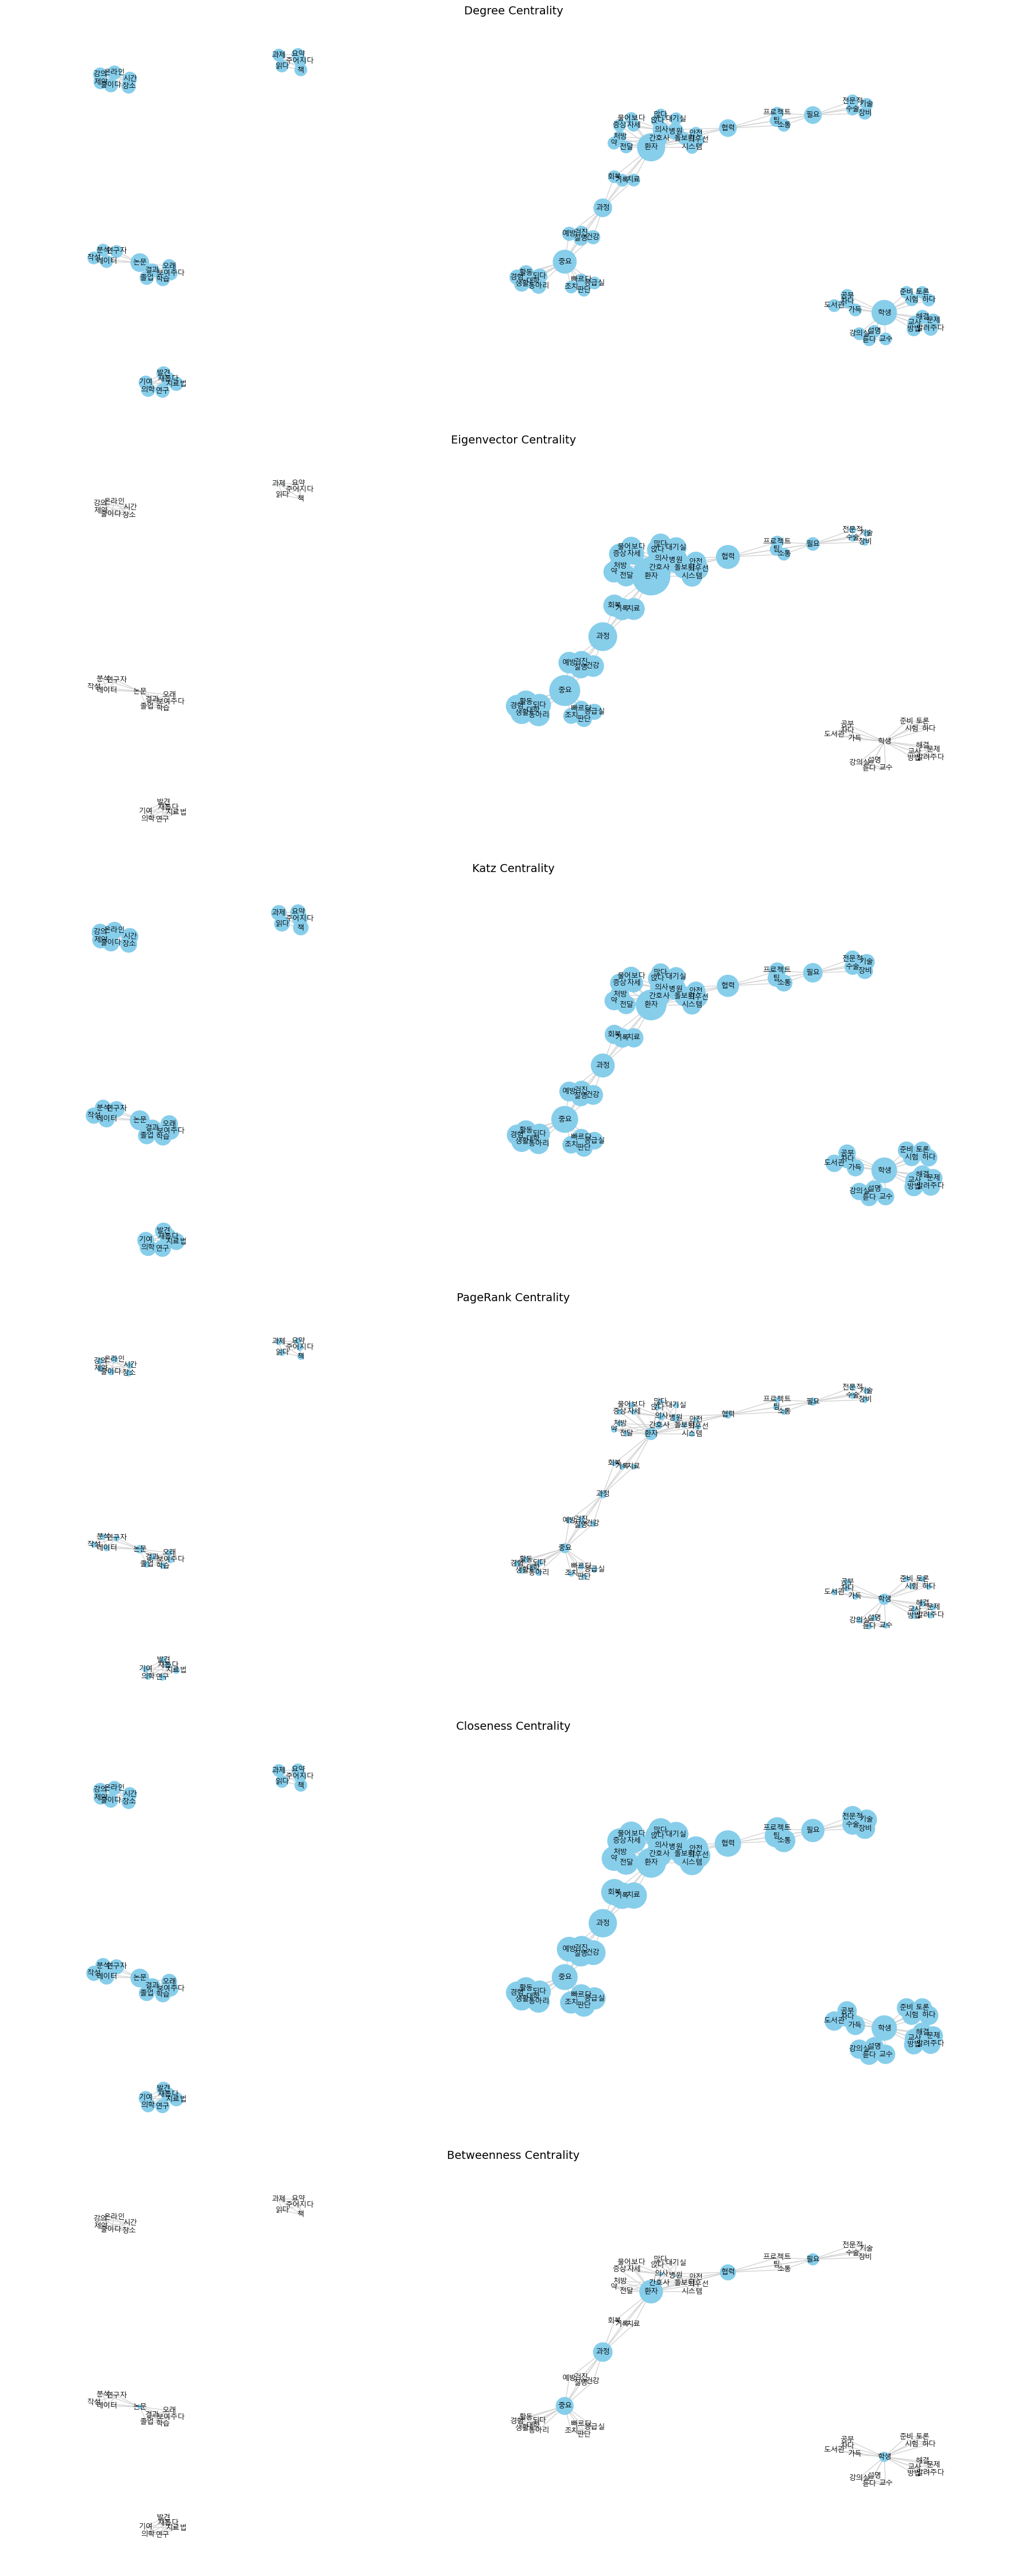

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# 중심성 지표들
centralities = {
    'Degree': deg_c,
    'Eigenvector': eig_c,
    'Katz': katz_c,
    'PageRank': pr_c,
    'Closeness': clo_c,
    'Betweenness': btw_c
}

# 고정 레이아웃
pos = nx.spring_layout(G_count, seed=42)

# 시각화: 중심성별 subplot
fig, axes = plt.subplots(6, 1, figsize=(18, 45))
axes = axes.flatten()

for ax, (title, cent) in zip(axes, centralities.items()):
    node_sizes = [5000 * cent.get(node, 0) for node in G_count.nodes()]
    nx.draw_networkx(
        G_count,
        pos=pos,
        with_labels=True,
        font_family="Malgun Gothic",
        node_size=node_sizes,
        ax=ax,
        font_size=9,
        node_color='skyblue',
        edge_color='lightgray'
    )
    ax.set_title(f"{title} Centrality", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

자 결과가 어떻게 느껴지시나요? 토큰 네트워크에 매우 다양한 구조적 정보가 있음을 실감하실 수 있을 것입니다. 예를 들어 직접 연결에 기반한 degree centrality나 eigenvector centrality 계열에서는 '학생'이 꽤 높은 위치를 차지할 수 있지만, 간접 연결을 포함하여 전반적인 연결을 고려하는 closeness centrality와 betweenness centralty에서는 높기가 어렵죠. 그림에서 보다시피, 따로 떨어져 있거든요. 이처럼 지표들이 다른 구조적 정보를 강조하는 만큼, 분석자가 탐구하고자 하는 것이 무엇이냐에 따라 적절하게 지표를 활용해야 할 것입니다. 그리고 이처럼 네트워크의 구조적 정보를 고려하는 중심성 지표들은 마음의 구조를 탐구하는 과정에서 좋은 도구가 될 것입니다. 